In [26]:
import importlib, Saxo
importlib.reload(Saxo)
from Saxo import SaxoClient
import Key as Key
import pandas as pd


client = SaxoClient(
    app_key=Key.app_key,
    app_secret=Key.app_secret,
    app_name=Key.app_name,
    redirect_uri=Key.redirect_uri
)

# Remplace ton ancien login par celui-ci :
client.smart_login()

# Ton code de trading continue ici...
print(f"Solde cash : {client.get_cash()}")

📂 Jetons chargés depuis le fichier.
🔑 Token chargé et session prête.
✅ Session toujours active.
Solde cash : 105.78


In [27]:
a=client.get_positions()

In [28]:
ptf_exposure(a)

NameError: name 'ptf_exposure' is not defined

In [9]:
ISIN1="CH1522658686"
ISIN2="CH1227569022"
total1="FR0000120271"

In [10]:
info = client.info_needed_for_trading(total1)
print(info)

{'uic': 23255427, 'type': 'SrdOnStock'}


In [10]:
all_data = []  # Liste pour stocker chaque df journalier

for date in pd.date_range(start="2021-01-01", end="2021-06-01"):
    start_time = date.strftime("%Y-%m-%d") + "T09:00:00"
    end_time = date.strftime("%Y-%m-%d") + "T17:00:00"
    
    df = client.get_chart_data_range(
        uic=23255427, 
        start_time=start_time, 
        end_time=end_time, 
        asset_type="SrdOnStock",  # Ton type d’asset
        horizon=1
    )
    
    if df is not None and not df.empty:
        df["date"] = date  # Optional : ajouter une colonne jour
        all_data.append(df)



📊 Mode: UpTo | Date: 2021-01-01T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-02T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-03T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-04T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-05T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-06T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-07T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-08T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-09T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-10T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-11T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-12T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021-01-13T17:00:00Z | Count: 482 | Asset: SrdOnStock
📊 Mode: UpTo | Date: 2021

HTTPError: 401 Client Error: Unauthorized for url: https://gateway.saxobank.com/openapi/chart/v3/charts?Uic=23255427&AssetType=SrdOnStock&Horizon=1&Count=482&FieldGroups=Data&Mode=UpTo&Time=2021-01-19T17%3A00%3A00Z

In [3]:
import pandas as pd

# all_data contient déjà tes DataFrames individuels
# Exemple : all_data = [df1, df2, df3, ...]

# Concaténation finale
df_final = pd.concat(all_data, axis=0)

# Reset index si tu veux avoir une colonne "Time" plutôt que l'index
df_final = df_final.reset_index().rename(columns={"index": "Time"})

# Tri chronologique (optionnel mais recommandé)
df_final = df_final.sort_values("Time").reset_index(drop=True)

print(df_final.head())
print("Total de lignes :", len(df_final))

                       Time   Close   High  Interest     Low    Open   Volume  \
0 2021-06-03 07:23:00+00:00  39.690  39.76       0.0  39.690  39.725  10290.0   
1 2021-06-03 07:24:00+00:00  39.680  39.70       0.0  39.680  39.685   1919.0   
2 2021-06-03 07:25:00+00:00  39.670  39.67       0.0  39.670  39.670    477.0   
3 2021-06-03 07:26:00+00:00  39.655  39.69       0.0  39.655  39.690   3153.0   
4 2021-06-03 07:27:00+00:00  39.670  39.68       0.0  39.645  39.645   3127.0   

        date  
0 2021-06-03  
1 2021-06-03  
2 2021-06-03  
3 2021-06-03  
4 2021-06-03  
Total de lignes : 102666


In [4]:
df_final

,Time,Close,High,Interest,Low,Open,Volume,date
0,2021-06-03 07:23:00+00:00,39.690,39.76,0.0,39.690,39.725,10290.0,2021-06-03
1,2021-06-03 07:24:00+00:00,39.680,39.70,0.0,39.680,39.685,1919.0,2021-06-03
2,2021-06-03 07:25:00+00:00,39.670,39.67,0.0,39.670,39.670,477.0,2021-06-03
3,2021-06-03 07:26:00+00:00,39.655,39.69,0.0,39.655,39.690,3153.0,2021-06-03
4,2021-06-03 07:27:00+00:00,39.670,39.68,0.0,39.645,39.645,3127.0,2021-06-03
...,...,...,...,...,...,...,...,...
102661,2021-12-31 12:55:00+00:00,44.800,44.80,0.0,44.800,44.800,545.0,2022-01-01
102662,2021-12-31 13:00:00+00:00,44.630,44.63,0.0,44.630,44.630,794285.0,2022-01-01
102663,2021-12-31 13:00:00+00:00,44.630,44.63,0.0,44.630,44.630,794285.0,2021-12-31
102664,2021-12-31 13:01:00+00:00,44.630,44.63,0.0,44.630,44.630,5000.0,2021-12-31


In [5]:
df=pd.read_csv("TOTAL3.csv")
df

,Time,Close,High,Interest,Low,Open,Volume,date
0,2021-12-30 13:26:00+00:00,44.91,44.910,0.0,44.905,44.905,903.0,2022-01-01 00:00:00
1,2021-12-30 13:26:00+00:00,44.91,44.910,0.0,44.905,44.905,903.0,2022-01-02 00:00:00
2,2021-12-30 13:27:00+00:00,44.91,44.910,0.0,44.910,44.910,1208.0,2022-01-02 00:00:00
3,2021-12-30 13:27:00+00:00,44.91,44.910,0.0,44.910,44.910,1208.0,2022-01-01 00:00:00
4,2021-12-30 13:28:00+00:00,44.91,44.915,0.0,44.910,44.910,2105.0,2022-01-01 00:00:00
...,...,...,...,...,...,...,...,...
736009,2026-03-04 16:29:00+00:00,66.90,66.960,0.0,66.890,66.940,27263.0,2026-03-04
736010,2026-03-04 16:35:00+00:00,66.86,66.860,0.0,66.860,66.860,2151491.0,2026-03-04
736011,2026-03-04 16:36:00+00:00,66.86,66.860,0.0,66.860,66.860,25100.0,2026-03-04
736012,2026-03-04 16:38:00+00:00,66.86,66.860,0.0,66.860,66.860,5000.0,2026-03-04


In [6]:
#concatenate df_final with df on the "Time" column 
df_merged = pd.concat([df_final, df], ignore_index=True)
df_merged

,Time,Close,High,Interest,Low,Open,Volume,date
0,2021-06-03 07:23:00+00:00,39.690,39.76,0.0,39.690,39.725,10290.0,2021-06-03 00:00:00
1,2021-06-03 07:24:00+00:00,39.680,39.70,0.0,39.680,39.685,1919.0,2021-06-03 00:00:00
2,2021-06-03 07:25:00+00:00,39.670,39.67,0.0,39.670,39.670,477.0,2021-06-03 00:00:00
3,2021-06-03 07:26:00+00:00,39.655,39.69,0.0,39.655,39.690,3153.0,2021-06-03 00:00:00
4,2021-06-03 07:27:00+00:00,39.670,39.68,0.0,39.645,39.645,3127.0,2021-06-03 00:00:00
...,...,...,...,...,...,...,...,...
838675,2026-03-04 16:29:00+00:00,66.900,66.96,0.0,66.890,66.940,27263.0,2026-03-04
838676,2026-03-04 16:35:00+00:00,66.860,66.86,0.0,66.860,66.860,2151491.0,2026-03-04
838677,2026-03-04 16:36:00+00:00,66.860,66.86,0.0,66.860,66.860,25100.0,2026-03-04
838678,2026-03-04 16:38:00+00:00,66.860,66.86,0.0,66.860,66.860,5000.0,2026-03-04


In [7]:
df_merged.to_csv("TOTAL4.csv", index=False)

In [53]:
df=pd.read_csv("CH1227569022.csv")
df

,Time,CloseAsk,CloseBid,HighAsk,HighBid,LowAsk,LowBid,OpenAsk,OpenBid,Open,High,Low,Close,date
0,2025-01-31 08:26:00+00:00,4.246,4.236,4.247,4.237,4.246,4.236,4.247,4.237,4.242,4.242,4.241,4.241,2025-02-01
1,2025-01-31 08:26:00+00:00,4.246,4.236,4.247,4.237,4.246,4.236,4.247,4.237,4.242,4.242,4.241,4.241,2025-02-02
2,2025-01-31 08:27:00+00:00,4.250,4.240,4.250,4.240,4.246,4.236,4.246,4.236,4.241,4.245,4.241,4.245,2025-02-02
3,2025-01-31 08:27:00+00:00,4.250,4.240,4.250,4.240,4.246,4.236,4.246,4.236,4.241,4.245,4.241,4.245,2025-02-01
4,2025-01-31 08:30:00+00:00,4.254,4.244,4.254,4.244,4.250,4.240,4.250,4.240,4.245,4.249,4.245,4.249,2025-02-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189421,2026-02-27 20:50:00+00:00,6.554,6.524,6.560,6.530,6.554,6.524,6.558,6.528,6.543,6.545,6.539,6.539,2026-02-28
189422,2026-02-27 20:51:00+00:00,6.548,6.518,6.552,6.522,6.546,6.516,6.552,6.522,6.537,6.537,6.531,6.533,2026-02-28
189423,2026-02-27 20:52:00+00:00,6.546,6.516,6.548,6.518,6.546,6.516,6.548,6.518,6.533,6.533,6.531,6.531,2026-02-28
189424,2026-02-27 20:53:00+00:00,6.546,6.516,6.548,6.518,6.546,6.516,6.546,6.516,6.531,6.533,6.531,6.531,2026-02-28


In [54]:
# add an hour collone by extracting the hour & minute from the Time column
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour
df["Minute"] = pd.to_datetime(df["Time"]).dt.minute

In [55]:
df.drop_duplicates(subset=["Time"], inplace=True)
df

,Time,CloseAsk,CloseBid,HighAsk,HighBid,LowAsk,LowBid,OpenAsk,OpenBid,Open,High,Low,Close,date,Hour,Minute
0,2025-01-31 08:26:00+00:00,4.246,4.236,4.247,4.237,4.246,4.236,4.247,4.237,4.242,4.242,4.241,4.241,2025-02-01,8,26
2,2025-01-31 08:27:00+00:00,4.250,4.240,4.250,4.240,4.246,4.236,4.246,4.236,4.241,4.245,4.241,4.245,2025-02-02,8,27
4,2025-01-31 08:30:00+00:00,4.254,4.244,4.254,4.244,4.250,4.240,4.250,4.240,4.245,4.249,4.245,4.249,2025-02-01,8,30
6,2025-01-31 08:31:00+00:00,4.253,4.243,4.254,4.244,4.253,4.243,4.254,4.244,4.249,4.249,4.248,4.248,2025-02-01,8,31
8,2025-01-31 08:33:00+00:00,4.258,4.248,4.258,4.248,4.253,4.243,4.253,4.243,4.248,4.253,4.248,4.253,2025-02-01,8,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189421,2026-02-27 20:50:00+00:00,6.554,6.524,6.560,6.530,6.554,6.524,6.558,6.528,6.543,6.545,6.539,6.539,2026-02-28,20,50
189422,2026-02-27 20:51:00+00:00,6.548,6.518,6.552,6.522,6.546,6.516,6.552,6.522,6.537,6.537,6.531,6.533,2026-02-28,20,51
189423,2026-02-27 20:52:00+00:00,6.546,6.516,6.548,6.518,6.546,6.516,6.548,6.518,6.533,6.533,6.531,6.531,2026-02-28,20,52
189424,2026-02-27 20:53:00+00:00,6.546,6.516,6.548,6.518,6.546,6.516,6.546,6.516,6.531,6.533,6.531,6.531,2026-02-28,20,53


In [56]:
df_var = df.copy()

# Liste des colonnes sur lesquelles calculer les variations
cols = ["Close", "CloseAsk", "CloseBid",
        "High", "HighAsk", "HighBid",
        "Low", "LowAsk", "LowBid",
        "Open", "OpenAsk", "OpenBid"]

# Variation minute par minute
for c in cols:
    df_var[c] = df_var[c].diff()

# Les colonnes Time, date, Hour, Minute restent identiques
df_var.dropna(inplace=True)  # Supprimer les lignes avec des NaN (la première ligne de chaque jour)
df_var

,Time,CloseAsk,CloseBid,HighAsk,HighBid,LowAsk,LowBid,OpenAsk,OpenBid,Open,High,Low,Close,date,Hour,Minute
2,2025-01-31 08:27:00+00:00,0.004,0.004,0.003,0.003,0.000,0.000,-0.001,-0.001,-0.001,0.003,0.000,0.004,2025-02-02,8,27
4,2025-01-31 08:30:00+00:00,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,2025-02-01,8,30
6,2025-01-31 08:31:00+00:00,-0.001,-0.001,0.000,0.000,0.003,0.003,0.004,0.004,0.004,0.000,0.003,-0.001,2025-02-01,8,31
8,2025-01-31 08:33:00+00:00,0.005,0.005,0.004,0.004,0.000,0.000,-0.001,-0.001,-0.001,0.004,0.000,0.005,2025-02-01,8,33
10,2025-01-31 08:34:00+00:00,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.005,2025-02-02,8,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189421,2026-02-27 20:50:00+00:00,-0.004,-0.004,0.002,0.002,0.000,0.000,0.004,0.004,0.004,0.002,0.000,-0.004,2026-02-28,20,50
189422,2026-02-27 20:51:00+00:00,-0.006,-0.006,-0.008,-0.008,-0.008,-0.008,-0.006,-0.006,-0.006,-0.008,-0.008,-0.006,2026-02-28,20,51
189423,2026-02-27 20:52:00+00:00,-0.002,-0.002,-0.004,-0.004,0.000,0.000,-0.004,-0.004,-0.004,-0.004,0.000,-0.002,2026-02-28,20,52
189424,2026-02-27 20:53:00+00:00,0.000,0.000,0.000,0.000,0.000,0.000,-0.002,-0.002,-0.002,0.000,0.000,0.000,2026-02-28,20,53


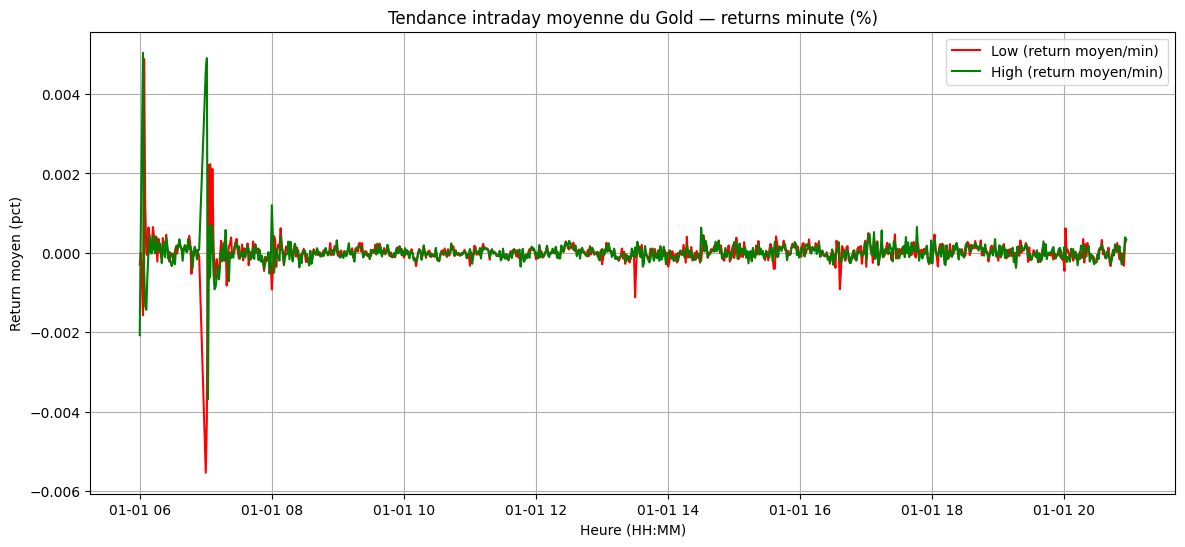

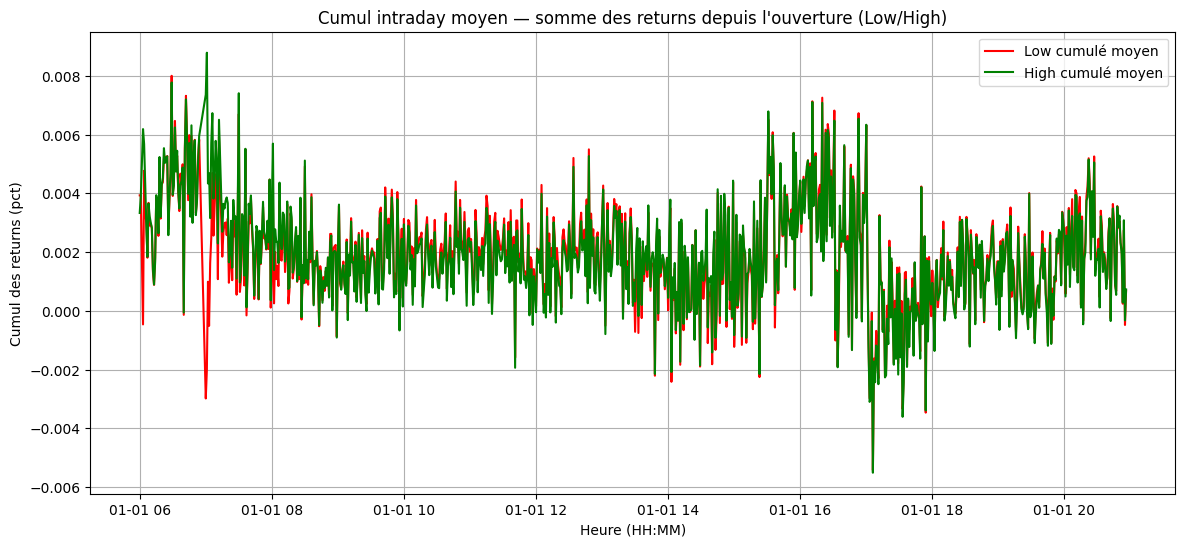

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) Colonnes numériques à traiter ---
price_cols = [
    "Close", "CloseAsk", "CloseBid",
    "High",  "HighAsk",  "HighBid",
    "Low",   "LowAsk",   "LowBid",
    "Open",  "OpenAsk",  "OpenBid"
]

# Copie de travail
df_ret = df.copy()

# --- 1) Assurer les types ---
# a) S'assurer que Time est une colonne (si c'est l'index, on le remet en colonne)
if "Time" not in df_ret.columns:
    df_ret = df_ret.reset_index()

# b) Time en datetime tz-aware (ne casse rien si c'est déjà le cas)
df_ret["Time"] = pd.to_datetime(df_ret["Time"], utc=True, errors="coerce")

# c) date en date (AAAA-MM-JJ)
#    Si 'date' n'existe pas, on la dérive de Time
if "date" not in df_ret.columns:
    df_ret["date"] = df_ret["Time"].dt.date
else:
    df_ret["date"] = pd.to_datetime(df_ret["date"], errors="coerce").dt.date

# d) Colonnes de prix => float
for c in price_cols:
    if c in df_ret.columns:
        df_ret[c] = pd.to_numeric(df_ret[c], errors="coerce")

# e) Tri chronologique pour des diffs corrects
df_ret = df_ret.sort_values("Time").reset_index(drop=True)

# --- 2) Returns minute par minute PAR JOUR (évite les diffs à cheval de 2 jours) ---
df_ret[price_cols] = (
    df_ret
      .groupby("date", group_keys=False)[price_cols]
      .pct_change()   # variation relative minute/minute
)

# --- 3) Clé intraday HH:MM (UTC). Si tu veux Paris, convertis d'abord le tz.
# df_ret["Time_local"] = df_ret["Time"].dt.tz_convert("Europe/Paris")
# df_ret["intraday_time"] = df_ret["Time_local"].dt.strftime("%H:%M")
df_ret["intraday_time"] = df_ret["Time"].dt.strftime("%H:%M")

# --- 4) Moyenne intraday minute -> pattern moyen de la journée ---
intraday_ret = (
    df_ret
      .groupby("intraday_time")[price_cols]
      .mean(numeric_only=True)   # ne moyenne que les numériques
)

# Index temps pour un plot propre
intraday_ret.index = pd.to_datetime(intraday_ret.index, format="%H:%M")
intraday_ret = intraday_ret.sort_index()

# --- 5) Plot : returns moyens par minute (Low & High) ---
plt.figure(figsize=(14, 6))
plt.plot(intraday_ret.index, intraday_ret["Low"],  label="Low (return moyen/min)",  color="red")
plt.plot(intraday_ret.index, intraday_ret["High"], label="High (return moyen/min)", color="green")
plt.title("Tendance intraday moyenne du Gold — returns minute (%)")
plt.xlabel("Heure (HH:MM)")
plt.ylabel("Return moyen (pct)")
plt.legend()
plt.grid(True)
plt.show()

# --- 6) (Optionnel) DataFrame cumulé : somme des variations depuis le début de chaque journée ---
df_cum = df_ret.copy()
df_cum[price_cols] = (
    df_cum
      .groupby("date", group_keys=False)[price_cols]
      .cumsum()   # cumul des returns depuis la 1ère minute de la journée
)

# df_cum contient le cumul intraday pour chaque minute et chaque jour
# Si tu veux en plus le "profil moyen cumulé" par minute de la journée :
intraday_cum = (
    df_cum
      .groupby("intraday_time")[price_cols]
      .mean(numeric_only=True)
)
intraday_cum.index = pd.to_datetime(intraday_cum.index, format="%H:%M")
intraday_cum = intraday_cum.sort_index()

# Exemple de tracé cumulé (facultatif) :
plt.figure(figsize=(14, 6))
plt.plot(intraday_cum.index, intraday_cum["Low"],  label="Low cumulé moyen",  color="red")
plt.plot(intraday_cum.index, intraday_cum["High"], label="High cumulé moyen", color="green")
plt.title("Cumul intraday moyen — somme des returns depuis l'ouverture (Low/High)")
plt.xlabel("Heure (HH:MM)")
plt.ylabel("Cumul des returns (pct)")
plt.legend(); plt.grid(True); plt.show()


In [58]:
import pandas as pd

# --- Colonnes numériques à traiter ---
price_cols = [
    "Close", "CloseAsk", "CloseBid",
    "High", "HighAsk", "HighBid",
    "Low", "LowAsk", "LowBid",
    "Open", "OpenAsk", "OpenBid"
]

df_cum = df.copy()

# 1) Assurer les types
df_cum["Time"] = pd.to_datetime(df_cum["Time"], utc=True, errors="coerce")
df_cum["date"] = pd.to_datetime(df_cum["date"], errors="coerce").dt.date

for c in price_cols:
    df_cum[c] = pd.to_numeric(df_cum[c], errors="coerce")

# 2) Trier chronologiquement
df_cum = df_cum.sort_values("Time")

# 3) Calculer les variations MINUTE → MINUTE par JOUR (relative ou absolue)
# --- tu utilisais pct_change(), donc je garde pct_change ---
df_cum[price_cols] = (
    df_cum
    .groupby("date", group_keys=False)[price_cols]
    .pct_change()     # variation relative minute/minute
)

# 4) Calcul des CUMULS depuis l'ouverture de la journée
df_cum_sum = df_cum.copy()
df_cum_sum[price_cols] = (
    df_cum_sum
    .groupby("date", group_keys=False)[price_cols]
    .cumsum()
)

# 5) Ajouter intraday time HH:MM si besoin
df_cum_sum["intraday_time"] = df_cum_sum["Time"].dt.strftime("%H:%M")
df.dropna(inplace=True)  # Supprimer les lignes avec des NaN (la première ligne de chaque jour)
df_cum_sum.head()

,Time,CloseAsk,CloseBid,HighAsk,HighBid,LowAsk,LowBid,OpenAsk,OpenBid,Open,High,Low,Close,date,Hour,Minute,intraday_time
0,2025-01-31 08:26:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-01,8,26,08:26
2,2025-01-31 08:27:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-02,8,27,08:27
4,2025-01-31 08:30:00+00:00,0.001884,0.001889,0.001648,0.001652,0.000942,0.000944,0.000706,0.000708,0.000707,0.001650,0.000943,0.001886,2025-02-01,8,30,08:30
6,2025-01-31 08:31:00+00:00,0.001649,0.001653,0.001648,0.001652,0.001648,0.001652,0.001648,0.001651,0.001649,0.001650,0.001650,0.001651,2025-02-01,8,31,08:31
8,2025-01-31 08:33:00+00:00,0.002825,0.002831,0.002589,0.002595,0.001648,0.001652,0.001412,0.001416,0.001414,0.002592,0.001650,0.002828,2025-02-01,8,33,08:33


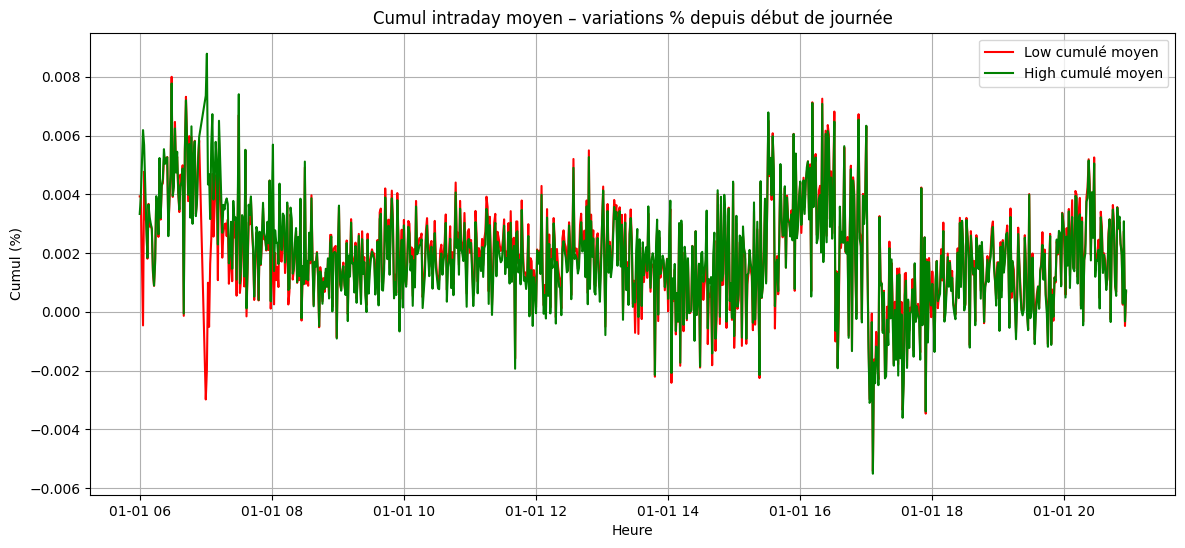

In [59]:
df_plot = (
    df_cum_sum
    .groupby("intraday_time")[price_cols]
    .mean()
)

df_plot.index = pd.to_datetime(df_plot.index, format="%H:%M")
df_plot = df_plot.sort_index()

plt.figure(figsize=(14, 6))
plt.plot(df_plot.index, df_plot["Low"], label="Low cumulé moyen", color="red")
plt.plot(df_plot.index, df_plot["High"], label="High cumulé moyen", color="green")
plt.title("Cumul intraday moyen – variations % depuis début de journée")
plt.xlabel("Heure")
plt.ylabel("Cumul (%)")
plt.grid()
plt.legend()
plt.show()